# Effect of Background Concentration (`C0`) on Two-Component Model

This notebook uses the overall best refined two-component parameters from:

`two_components/outputs/phase_exploitation/overall_best_refined_solution.csv`

It simulates four background concentrations (`C0 = 0.0, 2.3, 4.6, 6.9 mg/L`) and plots `C - C0` vs time for three fracture retardation factors:

- `R_f = 1.0`
- `R_f = 1.5`
- `R_f = 3.0`

Each figure section is followed by an Excel export cell that writes tabular results to `tabular_results/`.

## Background-relative equation used here

This notebook uses the following sequence for each background value `C0`:

1. RELAP returns component curves:
   - `C1_100(t)`
   - `C2_100(t)`

2. Convert each component to background-relative form:

```text
C1_R(t) = C1_100(t) - C0
C2_R(t) = C2_100(t) - C0
```

3. Build the two-component equivalent (relative to background):

```text
Ceq_R(t) = f1 * C1_R(t) + f2 * C2_R(t)
```

Equivalent expanded form:

```text
Ceq_R(t) = f1 * (C1_100(t) - C0) + f2 * (C2_100(t) - C0)
         = (f1*C1_100(t) + f2*C2_100(t)) - (f1 + f2)*C0
```

All figures plot `Ceq_R(t)` (shown as `C - C0`) versus time.

## 1) Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2) Read required inputs

In [2]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from reactive_transport.simulation_options_2 import simulateDualPorosity

best_csv = repo_root / "two_components/outputs/phase_exploitation/overall_best_refined_solution.csv"
best_df = pd.read_csv(best_csv)

best_row = best_df.loc[best_df["best_J"].idxmin()]

mrt1_best = float(best_row["best_MRT1"])
mrt2_best = float(best_row["best_MRT2"])
pe1_best = float(best_row["best_Pe1"])
pe2_best = float(best_row["best_Pe2"])
fr1_best = float(best_row["best_fr1"])
fr2_best = float(best_row["best_fr2"])

best_df.head()

,basin_id,ref_run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,best_J,nit,nfev,success,message
0,19,2,202,11.475848,48.819593,15.32661,2.034558,0.265815,0.671666,0.030909,59,5387,True,Optimization terminated successfully.


## 3) Define two-component simulation functions

In [3]:
def _c0_tag(c0):
    return f"{c0:.1f}".replace(".", "p")


def modelRELAP_single(
    t,
    mrt,
    pec,
    fracture_retardation,
    bckgrnd_conc,
    dpParam=0.0,
    matrix_retardation=1.0,
):
    inj_concs = np.array([7.0, bckgrnd_conc], dtype=float)
    inj_durs = np.cumsum(np.array([1.5], dtype=float))
    recRatio = 0.0
    wsCoef = 0.0

    return np.asarray(
        simulateDualPorosity(
            mrt,
            pec,
            fracture_retardation,
            t,
            bckgrnd_conc,
            inj_concs,
            inj_durs,
            dpParam,
            matrix_retardation,
            recRatio=recRatio,
            wsCoef=wsCoef,
            delay_time=0,
        ),
        dtype=float,
    )

## 4) Scenario A: Fracture retardation factor `R_f = 1.0`

In [4]:
background_values = [0.0, 2.3, 4.6, 6.9]
fracture_retardation_rf_1p0 = 1.0
t_plot_rf_1p0 = np.linspace(0.01, 60.0, 50)
results_rf_1p0 = {}

for c0 in background_values:
    c1_100 = modelRELAP_single(t_plot_rf_1p0, mrt1_best, pe1_best, fracture_retardation_rf_1p0, c0)
    c2_100 = modelRELAP_single(t_plot_rf_1p0, mrt2_best, pe2_best, fracture_retardation_rf_1p0, c0)

    c1_rel = c1_100 - c0
    c2_rel = c2_100 - c0
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel

    results_rf_1p0[c0] = {
        "C_eq_rel": c_eq_rel,
    }

results_rf_1p0[0.0]["C_eq_rel"][:5]

array([3.50690011e-97, 3.02144106e-09, 9.26240398e-05, 4.29745277e-03,
       3.67021257e-02])

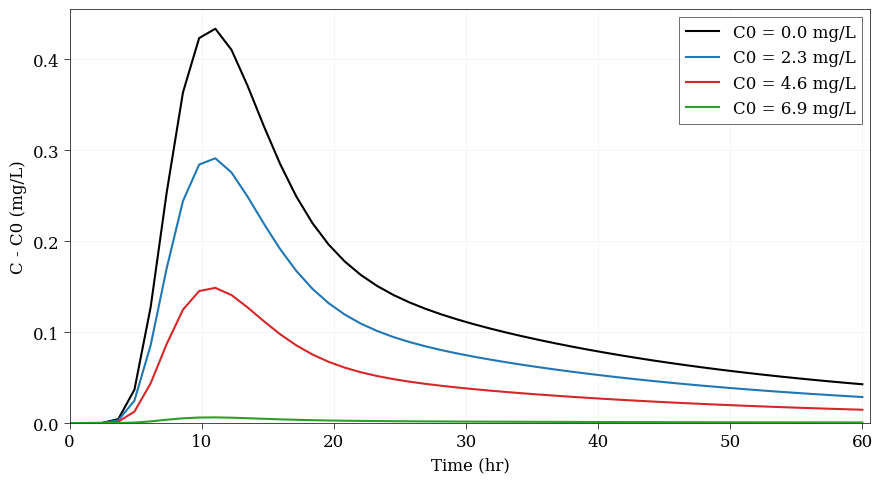

In [5]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

line_colors = {
    0.0: "black",
    2.3: "#1f77b4",
    4.6: "#d62728",
    6.9: "#2ca02c",
}

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for c0 in background_values:
        ax.plot(
            t_plot_rf_1p0,
            results_rf_1p0[c0]["C_eq_rel"],
            color=line_colors[c0],
            linewidth=_pt,
            label=f"C0 = {c0:.1f} mg/L",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C - C0 (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_max = max(np.max(results_rf_1p0[c0]["C_eq_rel"]) for c0 in background_values)
    ax.set_xlim(0, float(np.max(t_plot_rf_1p0)) * 1.01)
    ax.set_ylim(0, float(y_max) * 1.05)

    leg = ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/effect_of_C_BKG_rf_1p0.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [6]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_rf_1p0 = pd.DataFrame({"time_hr": t_plot_rf_1p0})

for c0 in background_values:
    tag = _c0_tag(c0)
    df_rf_1p0[f"C_eq_rel_C0_{tag}_mgL"] = results_rf_1p0[c0]["C_eq_rel"]

out_xlsx_rf_1p0 = tabular_results_dir / "effect_of_C_BKG_rf_1p0.xlsx"
df_rf_1p0.to_excel(out_xlsx_rf_1p0, index=False)
out_xlsx_rf_1p0

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/effect_of_C_BKG_rf_1p0.xlsx')

## 5) Scenario B: Fracture retardation factor `R_f = 1.5`

In [7]:
background_values = [0.0, 2.3, 4.6, 6.9]
fracture_retardation_rf_1p5 = 1.5
t_plot_rf_1p5 = np.linspace(0.01, 60.0, 50)
results_rf_1p5 = {}

for c0 in background_values:
    c1_100 = modelRELAP_single(t_plot_rf_1p5, mrt1_best, pe1_best, fracture_retardation_rf_1p5, c0)
    c2_100 = modelRELAP_single(t_plot_rf_1p5, mrt2_best, pe2_best, fracture_retardation_rf_1p5, c0)

    c1_rel = c1_100 - c0
    c2_rel = c2_100 - c0
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel

    results_rf_1p5[c0] = {
        "C_eq_rel": c_eq_rel,
    }

results_rf_1p5[0.0]["C_eq_rel"][:5]

array([2.25277862e-119, 9.76137807e-012, 4.74389761e-007, 9.12040135e-005,
       1.50233816e-003])

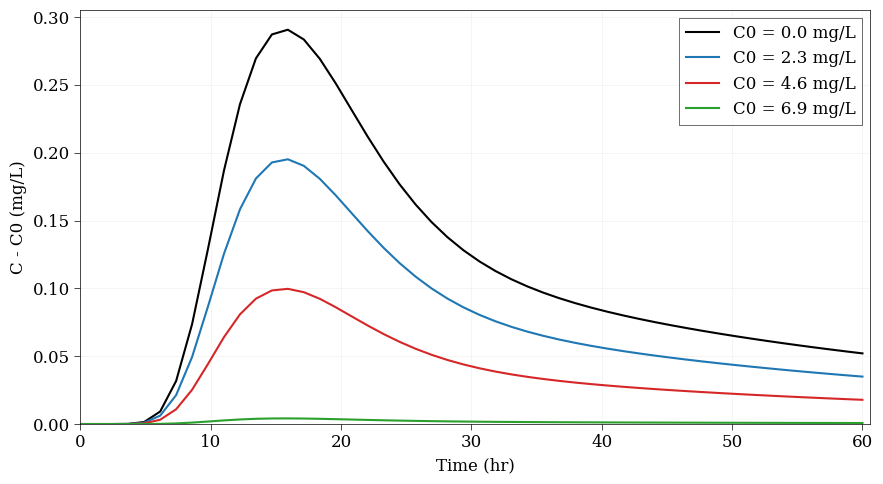

In [8]:
with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for c0 in background_values:
        ax.plot(
            t_plot_rf_1p5,
            results_rf_1p5[c0]["C_eq_rel"],
            color=line_colors[c0],
            linewidth=_pt,
            label=f"C0 = {c0:.1f} mg/L",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C - C0 (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_max = max(np.max(results_rf_1p5[c0]["C_eq_rel"]) for c0 in background_values)
    ax.set_xlim(0, float(np.max(t_plot_rf_1p5)) * 1.01)
    ax.set_ylim(0, float(y_max) * 1.05)

    leg = ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/effect_of_C_BKG_rf_1p5.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [9]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_rf_1p5 = pd.DataFrame({"time_hr": t_plot_rf_1p5})

for c0 in background_values:
    tag = _c0_tag(c0)
    df_rf_1p5[f"C_eq_rel_C0_{tag}_mgL"] = results_rf_1p5[c0]["C_eq_rel"]

out_xlsx_rf_1p5 = tabular_results_dir / "effect_of_C_BKG_rf_1p5.xlsx"
df_rf_1p5.to_excel(out_xlsx_rf_1p5, index=False)
out_xlsx_rf_1p5

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/effect_of_C_BKG_rf_1p5.xlsx')

## 6) Scenario C: Fracture retardation factor `R_f = 3.0`

In [10]:
background_values = [0.0, 2.3, 4.6, 6.9]
fracture_retardation_rf_3p0 = 3.0
t_plot_rf_3p0 = np.linspace(0.1, 60, 50)
results_rf_3p0 = {}

for c0 in background_values:
    c1_100 = modelRELAP_single(t_plot_rf_3p0, mrt1_best, pe1_best, fracture_retardation_rf_3p0, c0)
    c2_100 = modelRELAP_single(t_plot_rf_3p0, mrt2_best, pe2_best, fracture_retardation_rf_3p0, c0)

    c1_rel = c1_100 - c0
    c2_rel = c2_100 - c0
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel

    results_rf_3p0[c0] = {
        "C_eq_rel": c_eq_rel,
    }

results_rf_3p0[0.0]["C_eq_rel"][:5]

array([1.25195838e-52, 2.59670392e-14, 8.80545579e-12, 4.17595247e-09,
       5.94573177e-07])

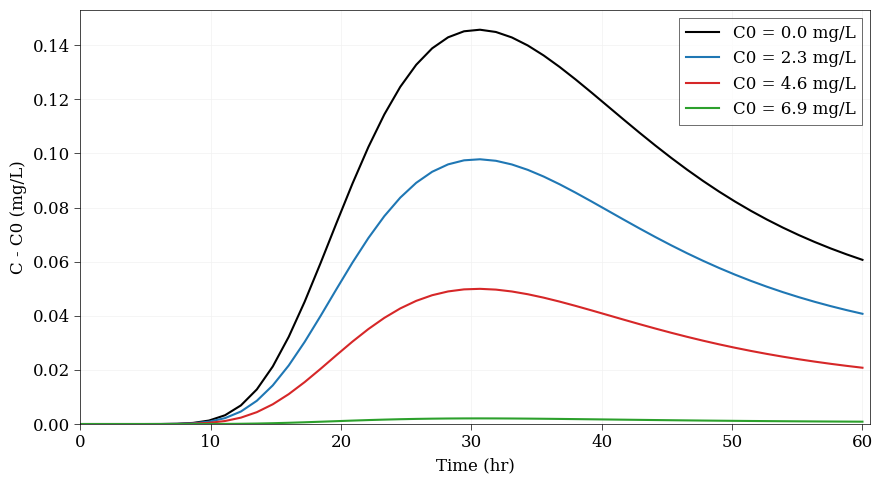

In [11]:
with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for c0 in background_values:
        ax.plot(
            t_plot_rf_3p0,
            results_rf_3p0[c0]["C_eq_rel"],
            color=line_colors[c0],
            linewidth=_pt,
            label=f"C0 = {c0:.1f} mg/L",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C - C0 (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_max = max(np.max(results_rf_3p0[c0]["C_eq_rel"]) for c0 in background_values)
    ax.set_xlim(0, float(np.max(t_plot_rf_3p0)) * 1.01)
    ax.set_ylim(0, float(y_max) * 1.05)

    leg = ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/effect_of_C_BKG_rf_3p0.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [12]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_rf_3p0 = pd.DataFrame({"time_hr": t_plot_rf_3p0})

for c0 in background_values:
    tag = _c0_tag(c0)
    df_rf_3p0[f"C_eq_rel_C0_{tag}_mgL"] = results_rf_3p0[c0]["C_eq_rel"]

out_xlsx_rf_3p0 = tabular_results_dir / "effect_of_C_BKG_rf_3p0.xlsx"
df_rf_3p0.to_excel(out_xlsx_rf_3p0, index=False)
out_xlsx_rf_3p0

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/effect_of_C_BKG_rf_3p0.xlsx')

## 7) Single vs dual porosity comparison (`R_f = 1.5`, `C0 = 2.3 mg/L`)

This section compares three cases using the same two-component calibrated parameters:

- Single porosity: `dpParam = 0.0`, `matrix_retardation = 1.0`
- Dual porosity (`matrix_retardation = 1`): `dpParam = 0.155`, `matrix_retardation = 1.0`
- Dual porosity (matrix retardation = 10): `dpParam = 0.155`, `matrix_retardation = 10.0`

For each case, the plotted curve is `Ceq_R(t) = C - C0`.

In [13]:
fracture_retardation_compare = 1.5
background_compare = 2.3
t_plot_compare = np.linspace(0.01, 60.0, 50)

comparison_cases = {
    "single_porosity": {"dpParam": 0.0, "matrix_retardation": 1.0},
    "dual_porosity_mr1": {"dpParam": 0.155, "matrix_retardation": 1.0},
    "dual_porosity_mr10": {"dpParam": 0.155, "matrix_retardation": 10.0},
}

results_compare = {}

for case_name, case_params in comparison_cases.items():
    c1_100 = modelRELAP_single(
        t_plot_compare,
        mrt1_best,
        pe1_best,
        fracture_retardation_compare,
        background_compare,
        dpParam=case_params["dpParam"],
        matrix_retardation=case_params["matrix_retardation"],
    )
    c2_100 = modelRELAP_single(
        t_plot_compare,
        mrt2_best,
        pe2_best,
        fracture_retardation_compare,
        background_compare,
        dpParam=case_params["dpParam"],
        matrix_retardation=case_params["matrix_retardation"],
    )

    c1_rel = c1_100 - background_compare
    c2_rel = c2_100 - background_compare
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel

    results_compare[case_name] = {
        "C_eq_rel": c_eq_rel,
    }

results_compare["single_porosity"]["C_eq_rel"][:5]

array([0.00000000e+00, 6.55403071e-12, 3.18518840e-07, 6.12369805e-05,
       1.00871277e-03])

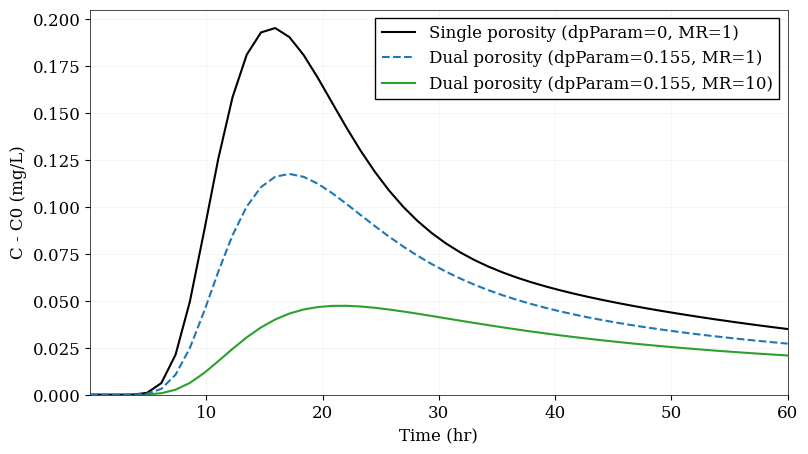

In [14]:
with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    ax.plot(
        t_plot_compare,
        results_compare["single_porosity"]["C_eq_rel"],
        color="black",
        linewidth=_pt,
        linestyle="-",
        zorder=3,
        label="Single porosity (dpParam=0, MR=1)",
    )
    ax.plot(
        t_plot_compare,
        results_compare["dual_porosity_mr1"]["C_eq_rel"],
        color="#1f77b4",
        linewidth=_pt,
        linestyle="--",
        zorder=4,
        label="Dual porosity (dpParam=0.155, MR=1)",
    )
    ax.plot(
        t_plot_compare,
        results_compare["dual_porosity_mr10"]["C_eq_rel"],
        color="#2ca02c",
        linewidth=_pt,
        linestyle="-",
        zorder=2,
        label="Dual porosity (dpParam=0.155, MR=10)",
    )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C - C0 (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_linewidth(_pt_hair)

    ax.legend(loc="upper right", frameon=True, fancybox=False, framealpha=1)

    ax.set_xlim(float(t_plot_compare.min()), float(t_plot_compare.max()))
    ax.set_ylim(bottom=0)

    plt.show()

# fig.savefig(
#     repo_root / "Figures" / "single_vs_dual_porosity_rf_1p5_c0_2p3.png",
#     dpi=600,
#     bbox_inches="tight",
#     pad_inches=0.02,
# )

In [15]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

comparison_export = pd.DataFrame({"time_hr": t_plot_compare})
bg_tag_compare = _c0_tag(background_compare)

comparison_export[f"C_eq_rel_C0_{bg_tag_compare}_mgL_single_porosity"] = results_compare["single_porosity"]["C_eq_rel"]
comparison_export[f"C_eq_rel_C0_{bg_tag_compare}_mgL_dual_porosity_mr1"] = results_compare["dual_porosity_mr1"]["C_eq_rel"]
comparison_export[f"C_eq_rel_C0_{bg_tag_compare}_mgL_dual_porosity_mr10"] = results_compare["dual_porosity_mr10"]["C_eq_rel"]

comparison_path = tabular_results_dir / "single_vs_dual_porosity_rf_1p5_c0_2p3.xlsx"
comparison_export.to_excel(comparison_path, index=False)
comparison_path

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/single_vs_dual_porosity_rf_1p5_c0_2p3.xlsx')